<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B04_Verificar_Exito_FaceSwap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B04 — Verificar cuantitativamente el éxito del face swap

Este notebook verifica que los deepfakes generados en B02 **realmente cambiaron la identidad facial hacia el source**.

La idea es independiente de TrustMark:

```text
source
  ↓ identidad esperada

target original
  ↓ identidad original

fake_control
fake_watermarked
  ↓
¿se parecen facialmente más al source que al target?
```

Para evitar evaluar SimSwap con exactamente el mismo modelo de identidad utilizado internamente por el generador, aquí se utiliza un **verificador independiente** basado en `facenet-pytorch` con `InceptionResnetV1` preentrenado en VGGFace2.

B04 no pretende establecer una decisión biométrica definitiva. En este smoke test se utiliza un criterio **relativo y pareado** para comprobar si la identidad del fake se desplazó hacia el source.


## Métricas principales

Para cada par se calculan embeddings faciales y similitud coseno.

Sea:

```text
S = source
T = target original
F = fake
```

Se calculan:

```text
sim(S, T)
sim(S, F)
sim(T, F)
```

y dos cantidades muy fáciles de interpretar:

```text
shift_to_source = sim(S,F) - sim(S,T)
identity_margin = sim(S,F) - sim(T,F)
```

En este piloto consideraremos evidencia relativa de un face swap exitoso cuando:

```text
shift_to_source > 0
y
identity_margin > 0
```

Es decir:

1. el fake es más parecido al source que lo que era el target original;
2. el fake es más parecido al source que al target.

Este criterio se aplica por separado a `fake_control` y `fake_watermarked`.


In [ ]:
# ============================================================
# CELDA 1 — Instalación del verificador facial independiente
# Instala facenet-pytorch sin modificar las versiones principales
# de PyTorch/Torchvision del runtime. Se utiliza InceptionResnetV1
# preentrenado en VGGFace2 junto con MTCNN para detección y
# alineación facial.
# ============================================================

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("facenet_pytorch") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-deps",
        "facenet-pytorch==2.6.0",
    ])

print("✓ facenet-pytorch disponible.")


✓ facenet-pytorch disponible.


In [ ]:
# ============================================================
# CELDA 2 — Importaciones y dispositivo
# Importa las librerías para manejo de imágenes, embeddings,
# métricas de similitud, tablas y visualización. Si hay GPU se
# utiliza automáticamente; de lo contrario B04 puede ejecutarse
# también en CPU porque el smoke test es pequeño.
# ============================================================

from pathlib import Path
import json
import os
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from IPython.display import display

from facenet_pytorch import (
    MTCNN,
    InceptionResnetV1,
)

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [ ]:
# ============================================================
# CELDA 3 — Google Drive y estructura del proyecto
# Monta Google Drive, localiza el manifest de B02 y define las
# carpetas persistentes para métricas, crops faciales, figuras
# y configuración de B04.
# ============================================================

try:
    from google.colab import drive

    drive.mount("/content/drive")

    ROOT = Path(
        "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
    )

except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"


B02_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "simswap"
    / "smoke_10"
)

B02_MANIFEST = B02_ROOT / "manifest.csv"


OUT_ROOT = (
    ROOT
    / "results"
    / "grupo_B"
    / "face_swap_validation"
    / "smoke_10"
)

ALIGNED_DIR = OUT_ROOT / "aligned_faces"

OUT_METRICS = OUT_ROOT / "identity_metrics.csv"
OUT_SUMMARY = OUT_ROOT / "summary.csv"
OUT_CONFIG = OUT_ROOT / "config.json"


FIG_ROOT = (
    ROOT
    / "figures"
    / "grupo_B"
    / "face_swap_validation"
)

FIG_SOURCE_SIM = (
    FIG_ROOT
    / "source_similarity_control_vs_watermarked.png"
)

FIG_MARGIN = (
    FIG_ROOT
    / "identity_margin_control_vs_watermarked.png"
)

FIG_OUTPUT_SIM = (
    FIG_ROOT
    / "control_vs_watermarked_output_similarity.png"
)

FIG_ALIGNED = (
    FIG_ROOT
    / "aligned_faces_b04.png"
)


MODEL_CACHE = (
    ROOT
    / "models"
    / "facenet_pytorch"
)


for path in [
    OUT_ROOT,
    ALIGNED_DIR,
    FIG_ROOT,
    MODEL_CACHE,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )


# Hace persistente la descarga del modelo VGGFace2.
os.environ["TORCH_HOME"] = str(
    MODEL_CACHE
)


print("Manifest B02:")
print(B02_MANIFEST)
print()
print("Resultados B04:")
print(OUT_ROOT)


Mounted at /content/drive
Manifest B02:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/simswap/smoke_10/manifest.csv

Resultados B04:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/face_swap_validation/smoke_10


In [ ]:
# ============================================================
# CELDA 4 — Validación de las entradas de B02
# Comprueba que el manifest contiene las cuatro imágenes
# necesarias por par: source, target original, fake_control y
# fake_watermarked, y verifica que todos los archivos existen.
# ============================================================

assert B02_MANIFEST.exists(), (
    f"No se encontró el manifest de B02:\n{B02_MANIFEST}"
)

manifest_b02 = pd.read_csv(
    B02_MANIFEST
)


required_columns = {
    "pair_id",
    "source_frame",
    "target_original",
    "fake_control",
    "fake_watermarked",
}

missing_columns = (
    required_columns
    - set(manifest_b02.columns)
)

assert not missing_columns, (
    f"Faltan columnas en B02: {sorted(missing_columns)}"
)


for column in [
    "source_frame",
    "target_original",
    "fake_control",
    "fake_watermarked",
]:

    missing_files = [
        p
        for p in manifest_b02[
            column
        ].astype(str)
        if not Path(p).exists()
    ]

    assert not missing_files, (
        f"Hay archivos faltantes en {column}: "
        f"{missing_files[:3]}"
    )


print("✓ Entradas validadas.")
print("Número de pares:", len(manifest_b02))

display(
    manifest_b02[
        [
            "pair_id",
            "source_frame",
            "target_original",
            "fake_control",
            "fake_watermarked",
        ]
    ]
)


✓ Entradas validadas.
Número de pares: 5


,pair_id,source_frame,target_original,fake_control,fake_watermarked
0,pair_001,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
1,pair_002,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
2,pair_003,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
3,pair_004,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
4,pair_005,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...


In [ ]:
# ============================================================
# CELDA 5 — Inicialización del detector y modelo de identidad
# MTCNN detecta y alinea una cara por imagen. InceptionResnetV1
# transforma el rostro alineado en un embedding de 512 dimensiones
# que representa principalmente información de identidad facial.
# ============================================================

mtcnn = MTCNN(
    image_size=160,
    margin=20,
    keep_all=False,
    post_process=True,
    device=device,
)

identity_model = (
    InceptionResnetV1(
        pretrained="vggface2"
    )
    .eval()
    .to(device)
)


print("✓ MTCNN inicializado.")
print("✓ InceptionResnetV1/VGGFace2 inicializado.")


  0%|          | 0.00/107M [00:00<?, ?B/s]

✓ MTCNN inicializado.
✓ InceptionResnetV1/VGGFace2 inicializado.


In [ ]:
# ============================================================
# CELDA 6 — Funciones de embeddings y similitud
# Detecta el rostro, guarda el crop alineado para auditoría,
# obtiene el embedding facial normalizado y calcula similitud
# coseno entre pares de identidades.
# ============================================================

def l2_normalize(
    vector,
):
    norm = np.linalg.norm(
        vector
    )

    if norm == 0:
        return vector

    return (
        vector
        / norm
    )


def cosine_similarity(
    a,
    b,
):
    a = l2_normalize(
        np.asarray(a)
    )

    b = l2_normalize(
        np.asarray(b)
    )

    return float(
        np.dot(
            a,
            b,
        )
    )


def extract_embedding(
    image_path,
    aligned_output=None,
):

    image_path = Path(
        image_path
    )

    with Image.open(
        image_path
    ) as img:

        image = (
            img
            .convert("RGB")
            .copy()
        )


    face_tensor, probability = mtcnn(
        image,
        return_prob=True,
    )


    if face_tensor is None:
        return {
            "embedding": None,
            "detection_probability": np.nan,
            "face_detected": False,
        }


    if aligned_output is not None:

        aligned_output = Path(
            aligned_output
        )

        aligned_output.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        # El tensor post-procesado no se usa directamente para
        # visualizar; MTCNN vuelve a generar un crop sin
        # normalización y lo guarda para auditoría.
        mtcnn(
            image,
            save_path=str(
                aligned_output
            ),
        )


    with torch.no_grad():

        embedding = identity_model(
            face_tensor
            .unsqueeze(0)
            .to(device)
        )


    embedding = (
        embedding
        .detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )

    embedding = l2_normalize(
        embedding
    )


    return {
        "embedding": embedding,
        "detection_probability": float(
            probability
        )
        if probability is not None
        else np.nan,
        "face_detected": True,
    }


In [ ]:
# ============================================================
# CELDA 7 — Extraer embeddings para las cuatro imágenes
# Para cada par obtiene embeddings del source, target original,
# fake_control y fake_watermarked. También guarda los rostros
# alineados para inspeccionar qué región facial evaluó el modelo.
# ============================================================

embedding_records = {}


for row in manifest_b02.itertuples(
    index=False
):

    pair_id = str(
        row.pair_id
    )

    print(
        "Procesando",
        pair_id,
    )


    paths = {
        "source": Path(
            row.source_frame
        ),
        "target": Path(
            row.target_original
        ),
        "fake_control": Path(
            row.fake_control
        ),
        "fake_watermarked": Path(
            row.fake_watermarked
        ),
    }


    embedding_records[
        pair_id
    ] = {}


    for role, path in paths.items():

        aligned_path = (
            ALIGNED_DIR
            / f"{pair_id}_{role}.png"
        )


        result = extract_embedding(
            path,
            aligned_output=aligned_path,
        )


        embedding_records[
            pair_id
        ][role] = {
            **result,
            "image_path": str(
                path
            ),
            "aligned_path": str(
                aligned_path
            ),
        }


print("✓ Embeddings calculados.")


Procesando pair_001
Procesando pair_002
Procesando pair_003
Procesando pair_004
Procesando pair_005
✓ Embeddings calculados.


In [ ]:
# ============================================================
# CELDA 8 — Validación de detección facial
# Comprueba que MTCNN detectó una cara en todas las imágenes.
# Si alguna detección falla, B04 se detiene porque las métricas
# de identidad no serían comparables para ese par.
# ============================================================

detection_rows = []


for pair_id, roles in embedding_records.items():

    for role, info in roles.items():

        detection_rows.append({
            "pair_id": pair_id,
            "role": role,
            "face_detected": info[
                "face_detected"
            ],
            "detection_probability": info[
                "detection_probability"
            ],
        })


detection_table = pd.DataFrame(
    detection_rows
)


display(
    detection_table
)


if not detection_table[
    "face_detected"
].all():

    failed = detection_table[
        ~detection_table[
            "face_detected"
        ]
    ]

    display(
        failed
    )

    raise RuntimeError(
        "No se detectó una cara en todas las imágenes. "
        "Revisa los casos mostrados antes de continuar."
    )


print("✓ Todas las imágenes contienen una cara detectable.")


,pair_id,role,face_detected,detection_probability
0,pair_001,source,True,0.999971
1,pair_001,target,True,0.999757
2,pair_001,fake_control,True,0.999815
3,pair_001,fake_watermarked,True,0.999848
4,pair_002,source,True,0.999985
5,pair_002,target,True,0.994821
6,pair_002,fake_control,True,0.998526
7,pair_002,fake_watermarked,True,0.998517
8,pair_003,source,True,0.999903
9,pair_003,target,True,0.999956


✓ Todas las imágenes contienen una cara detectable.


In [ ]:
# ============================================================
# CELDA 9 — Métricas de identidad del face swap
# Calcula cuánto se acerca cada fake al source y cuánto conserva
# del target. También calcula shift_to_source e identity_margin,
# que forman el criterio relativo de éxito del smoke test.
# ============================================================

metric_rows = []


for row in manifest_b02.itertuples(
    index=False
):

    pair_id = str(
        row.pair_id
    )

    records = embedding_records[
        pair_id
    ]


    source = records[
        "source"
    ][
        "embedding"
    ]

    target = records[
        "target"
    ][
        "embedding"
    ]

    control = records[
        "fake_control"
    ][
        "embedding"
    ]

    watermarked = records[
        "fake_watermarked"
    ][
        "embedding"
    ]


    source_target_similarity = cosine_similarity(
        source,
        target,
    )


    for condition, fake_embedding in [
        (
            "fake_control",
            control,
        ),
        (
            "fake_watermarked",
            watermarked,
        ),
    ]:

        source_similarity = cosine_similarity(
            source,
            fake_embedding,
        )

        target_similarity = cosine_similarity(
            target,
            fake_embedding,
        )

        shift_to_source = (
            source_similarity
            - source_target_similarity
        )

        identity_margin = (
            source_similarity
            - target_similarity
        )

        relative_success = bool(
            shift_to_source > 0
            and identity_margin > 0
        )


        metric_rows.append({
            "pair_id": pair_id,
            "condition": condition,
            "source_target_similarity": (
                source_target_similarity
            ),
            "source_fake_similarity": (
                source_similarity
            ),
            "target_fake_similarity": (
                target_similarity
            ),
            "shift_to_source": (
                shift_to_source
            ),
            "identity_margin": (
                identity_margin
            ),
            "relative_swap_success": (
                relative_success
            ),
        })


identity_metrics = pd.DataFrame(
    metric_rows
)


display(
    identity_metrics
)


,pair_id,condition,source_target_similarity,source_fake_similarity,target_fake_similarity,shift_to_source,identity_margin,relative_swap_success
0,pair_001,fake_control,0.093868,0.605255,0.465716,0.511387,0.139539,True
1,pair_001,fake_watermarked,0.093868,0.607439,0.447869,0.513571,0.159570,True
2,pair_002,fake_control,-0.288797,0.668386,0.208297,0.957183,0.460089,True
3,pair_002,fake_watermarked,-0.288797,0.656575,0.219297,0.945371,0.437278,True
4,pair_003,fake_control,-0.221139,0.653174,0.234666,0.874313,0.418508,True
5,pair_003,fake_watermarked,-0.221139,0.670420,0.223756,0.891558,0.446663,True
6,pair_004,fake_control,0.018284,0.762932,0.325829,0.744648,0.437103,True
7,pair_004,fake_watermarked,0.018284,0.744765,0.312847,0.726481,0.431918,True
8,pair_005,fake_control,-0.112023,0.462328,0.362794,0.574351,0.099534,True
9,pair_005,fake_watermarked,-0.112023,0.462759,0.360452,0.574782,0.102307,True


In [ ]:
# ============================================================
# CELDA 10 — Comparación pareada control vs watermarked
# Compara directamente ambas ramas del experimento. Queremos que
# el fake generado desde el target marcado transfiera la identidad
# de forma prácticamente equivalente al fake_control.
# ============================================================

control_metrics = (
    identity_metrics[
        identity_metrics[
            "condition"
        ] == "fake_control"
    ]
    .set_index(
        "pair_id"
    )
)

watermarked_metrics = (
    identity_metrics[
        identity_metrics[
            "condition"
        ] == "fake_watermarked"
    ]
    .set_index(
        "pair_id"
    )
)


comparison_rows = []


for pair_id in control_metrics.index:

    c = control_metrics.loc[
        pair_id
    ]

    w = watermarked_metrics.loc[
        pair_id
    ]


    fake_control_embedding = (
        embedding_records[
            pair_id
        ][
            "fake_control"
        ][
            "embedding"
        ]
    )

    fake_watermarked_embedding = (
        embedding_records[
            pair_id
        ][
            "fake_watermarked"
        ][
            "embedding"
        ]
    )


    output_identity_similarity = cosine_similarity(
        fake_control_embedding,
        fake_watermarked_embedding,
    )


    comparison_rows.append({
        "pair_id": pair_id,
        "control_source_similarity": c[
            "source_fake_similarity"
        ],
        "watermarked_source_similarity": w[
            "source_fake_similarity"
        ],
        "delta_source_similarity_wm_minus_control": (
            w[
                "source_fake_similarity"
            ]
            - c[
                "source_fake_similarity"
            ]
        ),
        "control_identity_margin": c[
            "identity_margin"
        ],
        "watermarked_identity_margin": w[
            "identity_margin"
        ],
        "delta_margin_wm_minus_control": (
            w[
                "identity_margin"
            ]
            - c[
                "identity_margin"
            ]
        ),
        "fake_control_vs_fake_watermarked_identity_similarity": (
            output_identity_similarity
        ),
        "control_swap_success": bool(
            c[
                "relative_swap_success"
            ]
        ),
        "watermarked_swap_success": bool(
            w[
                "relative_swap_success"
            ]
        ),
    })


paired_comparison = pd.DataFrame(
    comparison_rows
)


display(
    paired_comparison
)


,pair_id,control_source_similarity,watermarked_source_similarity,delta_source_similarity_wm_minus_control,control_identity_margin,watermarked_identity_margin,delta_margin_wm_minus_control,fake_control_vs_fake_watermarked_identity_similarity,control_swap_success,watermarked_swap_success
0,pair_001,0.605255,0.607439,0.002184,0.139539,0.159570,0.020031,0.990764,True,True
1,pair_002,0.668386,0.656575,-0.011812,0.460089,0.437278,-0.022811,0.994546,True,True
2,pair_003,0.653174,0.670420,0.017245,0.418508,0.446663,0.028155,0.992159,True,True
3,pair_004,0.762932,0.744765,-0.018167,0.437103,0.431918,-0.005185,0.993775,True,True
4,pair_005,0.462328,0.462759,0.000431,0.099534,0.102307,0.002772,0.998771,True,True


In [ ]:
# ============================================================
# CELDA 11 — Similaridad visual entre las dos salidas
# Calcula PSNR y SSIM entre fake_control y fake_watermarked.
# Estas métricas no validan identidad por sí solas; sirven para
# cuantificar cuánto cambió visualmente el resultado de SimSwap
# al haber insertado TrustMark en el target.
# ============================================================

visual_rows = []


for row in manifest_b02.itertuples(
    index=False
):

    pair_id = str(
        row.pair_id
    )


    with Image.open(
        row.fake_control
    ) as img:

        control_img = np.asarray(
            img.convert("RGB"),
            dtype=np.uint8,
        )


    with Image.open(
        row.fake_watermarked
    ) as img:

        watermarked_img = np.asarray(
            img.convert("RGB"),
            dtype=np.uint8,
        )


    assert (
        control_img.shape
        == watermarked_img.shape
    )


    psnr = peak_signal_noise_ratio(
        control_img,
        watermarked_img,
        data_range=255,
    )


    ssim = structural_similarity(
        control_img,
        watermarked_img,
        channel_axis=2,
        data_range=255,
    )


    visual_rows.append({
        "pair_id": pair_id,
        "control_vs_watermarked_psnr": float(
            psnr
        ),
        "control_vs_watermarked_ssim": float(
            ssim
        ),
    })


visual_metrics = pd.DataFrame(
    visual_rows
)


paired_comparison = (
    paired_comparison
    .merge(
        visual_metrics,
        on="pair_id",
        how="left",
    )
)


display(
    paired_comparison
)


,pair_id,control_source_similarity,watermarked_source_similarity,delta_source_similarity_wm_minus_control,control_identity_margin,watermarked_identity_margin,delta_margin_wm_minus_control,fake_control_vs_fake_watermarked_identity_similarity,control_swap_success,watermarked_swap_success,control_vs_watermarked_psnr,control_vs_watermarked_ssim
0,pair_001,0.605255,0.607439,0.002184,0.139539,0.159570,0.020031,0.990764,True,True,42.558552,0.995066
1,pair_002,0.668386,0.656575,-0.011812,0.460089,0.437278,-0.022811,0.994546,True,True,42.018017,0.976321
2,pair_003,0.653174,0.670420,0.017245,0.418508,0.446663,0.028155,0.992159,True,True,41.828489,0.973269
3,pair_004,0.762932,0.744765,-0.018167,0.437103,0.431918,-0.005185,0.993775,True,True,43.453998,0.988617
4,pair_005,0.462328,0.462759,0.000431,0.099534,0.102307,0.002772,0.998771,True,True,44.866705,0.995480


In [ ]:
# ============================================================
# CELDA 12 — Resumen del smoke test
# Resume cuántos face swaps cumplen el criterio relativo y cuánto
# difieren las ramas control y watermarked. Con n=5 este resumen
# es descriptivo; no se realizan pruebas inferenciales todavía.
# ============================================================

summary = pd.DataFrame({
    "n_pairs": [
        len(
            paired_comparison
        )
    ],
    "control_success_count": [
        int(
            paired_comparison[
                "control_swap_success"
            ].sum()
        )
    ],
    "control_success_rate": [
        float(
            paired_comparison[
                "control_swap_success"
            ].mean()
        )
    ],
    "watermarked_success_count": [
        int(
            paired_comparison[
                "watermarked_swap_success"
            ].sum()
        )
    ],
    "watermarked_success_rate": [
        float(
            paired_comparison[
                "watermarked_swap_success"
            ].mean()
        )
    ],
    "mean_control_source_similarity": [
        float(
            paired_comparison[
                "control_source_similarity"
            ].mean()
        )
    ],
    "mean_watermarked_source_similarity": [
        float(
            paired_comparison[
                "watermarked_source_similarity"
            ].mean()
        )
    ],
    "mean_delta_source_similarity_wm_minus_control": [
        float(
            paired_comparison[
                "delta_source_similarity_wm_minus_control"
            ].mean()
        )
    ],
    "mean_control_identity_margin": [
        float(
            paired_comparison[
                "control_identity_margin"
            ].mean()
        )
    ],
    "mean_watermarked_identity_margin": [
        float(
            paired_comparison[
                "watermarked_identity_margin"
            ].mean()
        )
    ],
    "mean_fake_identity_similarity_control_vs_watermarked": [
        float(
            paired_comparison[
                "fake_control_vs_fake_watermarked_identity_similarity"
            ].mean()
        )
    ],
    "mean_control_vs_watermarked_psnr": [
        float(
            paired_comparison[
                "control_vs_watermarked_psnr"
            ].mean()
        )
    ],
    "mean_control_vs_watermarked_ssim": [
        float(
            paired_comparison[
                "control_vs_watermarked_ssim"
            ].mean()
        )
    ],
})


display(
    summary
)


,n_pairs,control_success_count,control_success_rate,watermarked_success_count,watermarked_success_rate,mean_control_source_similarity,mean_watermarked_source_similarity,mean_delta_source_similarity_wm_minus_control,mean_control_identity_margin,mean_watermarked_identity_margin,mean_fake_identity_similarity_control_vs_watermarked,mean_control_vs_watermarked_psnr,mean_control_vs_watermarked_ssim
0,5,5,1.0,5,1.0,0.630415,0.628391,-0.002024,0.310955,0.315547,0.994003,42.945152,0.985751


In [ ]:
# ============================================================
# CELDA 13 — Gate metodológico para interpretar B03
# Verifica si ambas condiciones lograron el cambio de identidad
# en todos los pares según el criterio relativo del piloto.
# Si algún caso falla, se identifica para inspección en lugar de
# asumir automáticamente que TrustMark sobrevivió a un ataque
# de deepfake exitoso.
# ============================================================

all_control_success = bool(
    paired_comparison[
        "control_swap_success"
    ].all()
)

all_watermarked_success = bool(
    paired_comparison[
        "watermarked_swap_success"
    ].all()
)


print(
    "Todos los fake_control exitosos:",
    all_control_success,
)

print(
    "Todos los fake_watermarked exitosos:",
    all_watermarked_success,
)


if not (
    all_control_success
    and all_watermarked_success
):

    failed = paired_comparison[
        ~(
            paired_comparison[
                "control_swap_success"
            ]
            & paired_comparison[
                "watermarked_swap_success"
            ]
        )
    ]

    print()
    print(
        "Pares que requieren inspección:"
    )

    display(
        failed
    )

else:

    print()
    print(
        "✓ Todos los pares muestran desplazamiento "
        "de identidad hacia el source en ambas condiciones."
    )


Todos los fake_control exitosos: True
Todos los fake_watermarked exitosos: True

✓ Todos los pares muestran desplazamiento de identidad hacia el source en ambas condiciones.


In [ ]:
# ============================================================
# CELDA 14 — Guardado de resultados y configuración
# Guarda métricas individuales, comparación pareada, resumen,
# versión del verificador y criterio operativo de éxito para
# garantizar reproducibilidad y trazabilidad del Grupo B.
# ============================================================

# Se guarda una tabla principal que incluye las métricas de
# identidad por condición.
identity_metrics.to_csv(
    OUT_METRICS,
    index=False,
)


paired_path = (
    OUT_ROOT
    / "paired_comparison.csv"
)

paired_comparison.to_csv(
    paired_path,
    index=False,
)


summary.to_csv(
    OUT_SUMMARY,
    index=False,
)


config = {
    "group": "B",
    "stage": "B04",
    "purpose": (
        "quantitative validation of face-swap identity transfer"
    ),
    "generator": "SimSwap",
    "independent_identity_verifier": (
        "facenet-pytorch InceptionResnetV1"
    ),
    "identity_pretraining": "VGGFace2",
    "face_detector": "MTCNN",
    "face_crop_size": 160,
    "face_crop_margin": 20,
    "embedding_dimension": 512,
    "similarity": "cosine",
    "relative_success_rule": (
        "shift_to_source > 0 AND identity_margin > 0"
    ),
    "shift_to_source": (
        "sim(source,fake) - sim(source,target)"
    ),
    "identity_margin": (
        "sim(source,fake) - sim(target,fake)"
    ),
    "note": (
        "Pilot operational criterion; not a calibrated biometric threshold."
    ),
    "n_pairs": int(
        len(
            manifest_b02
        )
    ),
    "input_manifest": str(
        B02_MANIFEST
    ),
    "identity_metrics": str(
        OUT_METRICS
    ),
    "paired_comparison": str(
        paired_path
    ),
    "summary": str(
        OUT_SUMMARY
    ),
    "aligned_faces": str(
        ALIGNED_DIR
    ),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "device": str(
        device
    ),
    "platform": platform.platform(),
}


with open(
    OUT_CONFIG,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("Métricas:")
print(OUT_METRICS)
print()
print("Comparación pareada:")
print(paired_path)
print()
print("Resumen:")
print(OUT_SUMMARY)
print()
print("Configuración:")
print(OUT_CONFIG)


Métricas:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/face_swap_validation/smoke_10/identity_metrics.csv

Comparación pareada:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/face_swap_validation/smoke_10/paired_comparison.csv

Resumen:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/face_swap_validation/smoke_10/summary.csv

Configuración:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/face_swap_validation/smoke_10/config.json


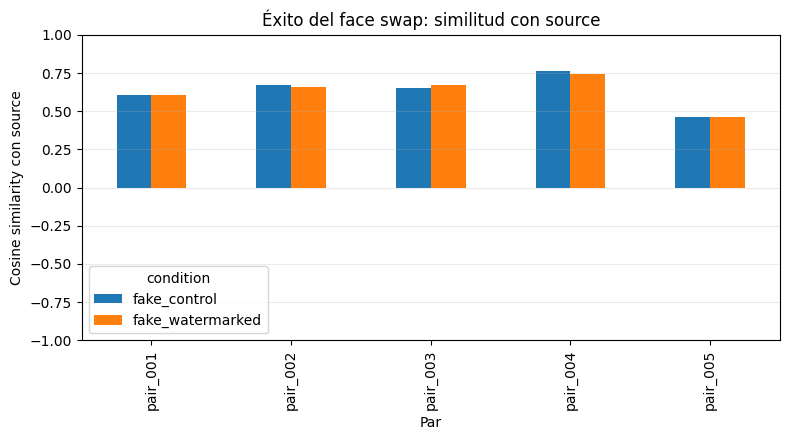

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/face_swap_validation/source_similarity_control_vs_watermarked.png


In [ ]:
# ============================================================
# CELDA 15 — Figura: similitud con el source
# Compara, par por par, cuánto se parecen al source el fake_control
# y el fake_watermarked. Si TrustMark no interfiere de forma
# importante, ambas curvas/barras deberían ser muy cercanas.
# ============================================================

pivot_source = (
    identity_metrics
    .pivot(
        index="pair_id",
        columns="condition",
        values="source_fake_similarity",
    )
    .sort_index()
)


ax = pivot_source.plot(
    kind="bar",
    figsize=(
        8,
        4.5,
    ),
)

ax.set_ylabel(
    "Cosine similarity con source"
)

ax.set_xlabel(
    "Par"
)

ax.set_title(
    "Éxito del face swap: similitud con source"
)

ax.set_ylim(
    -1,
    1,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_SOURCE_SIM,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_SOURCE_SIM)


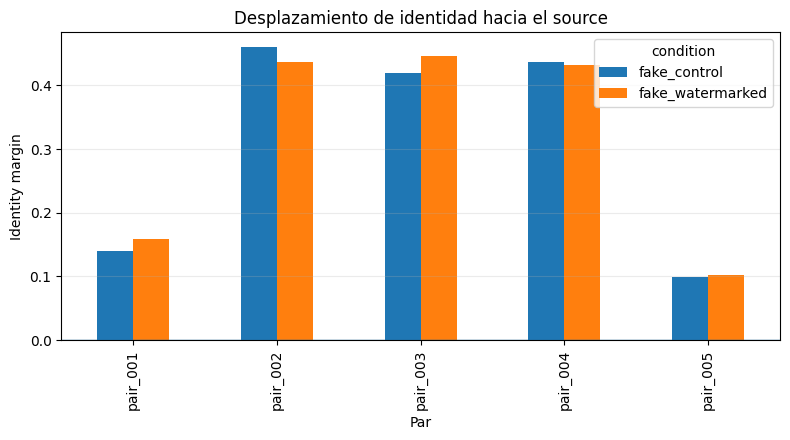

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/face_swap_validation/identity_margin_control_vs_watermarked.png


In [ ]:
# ============================================================
# CELDA 16 — Figura: margen de identidad
# Muestra identity_margin = sim(source,fake)-sim(target,fake).
# Valores positivos indican que el fake se parece más al source
# que al target según el verificador facial independiente.
# ============================================================

pivot_margin = (
    identity_metrics
    .pivot(
        index="pair_id",
        columns="condition",
        values="identity_margin",
    )
    .sort_index()
)


ax = pivot_margin.plot(
    kind="bar",
    figsize=(
        8,
        4.5,
    ),
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_ylabel(
    "Identity margin"
)

ax.set_xlabel(
    "Par"
)

ax.set_title(
    "Desplazamiento de identidad hacia el source"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_MARGIN,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_MARGIN)


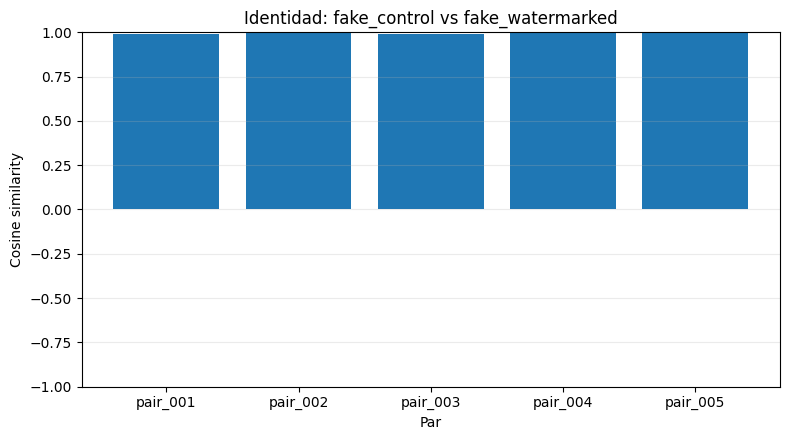

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/face_swap_validation/control_vs_watermarked_output_similarity.png


In [ ]:
# ============================================================
# CELDA 17 — Figura: similitud entre las dos salidas de SimSwap
# Visualiza cuán similares son, a nivel de identidad, el
# fake_control y el fake_watermarked de cada par. Valores cercanos
# a 1 indican resultados faciales muy similares entre condiciones.
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)

ax.bar(
    paired_comparison[
        "pair_id"
    ],
    paired_comparison[
        "fake_control_vs_fake_watermarked_identity_similarity"
    ],
)

ax.set_ylim(
    -1,
    1,
)

ax.set_ylabel(
    "Cosine similarity"
)

ax.set_xlabel(
    "Par"
)

ax.set_title(
    "Identidad: fake_control vs fake_watermarked"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    FIG_OUTPUT_SIM,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_OUTPUT_SIM)


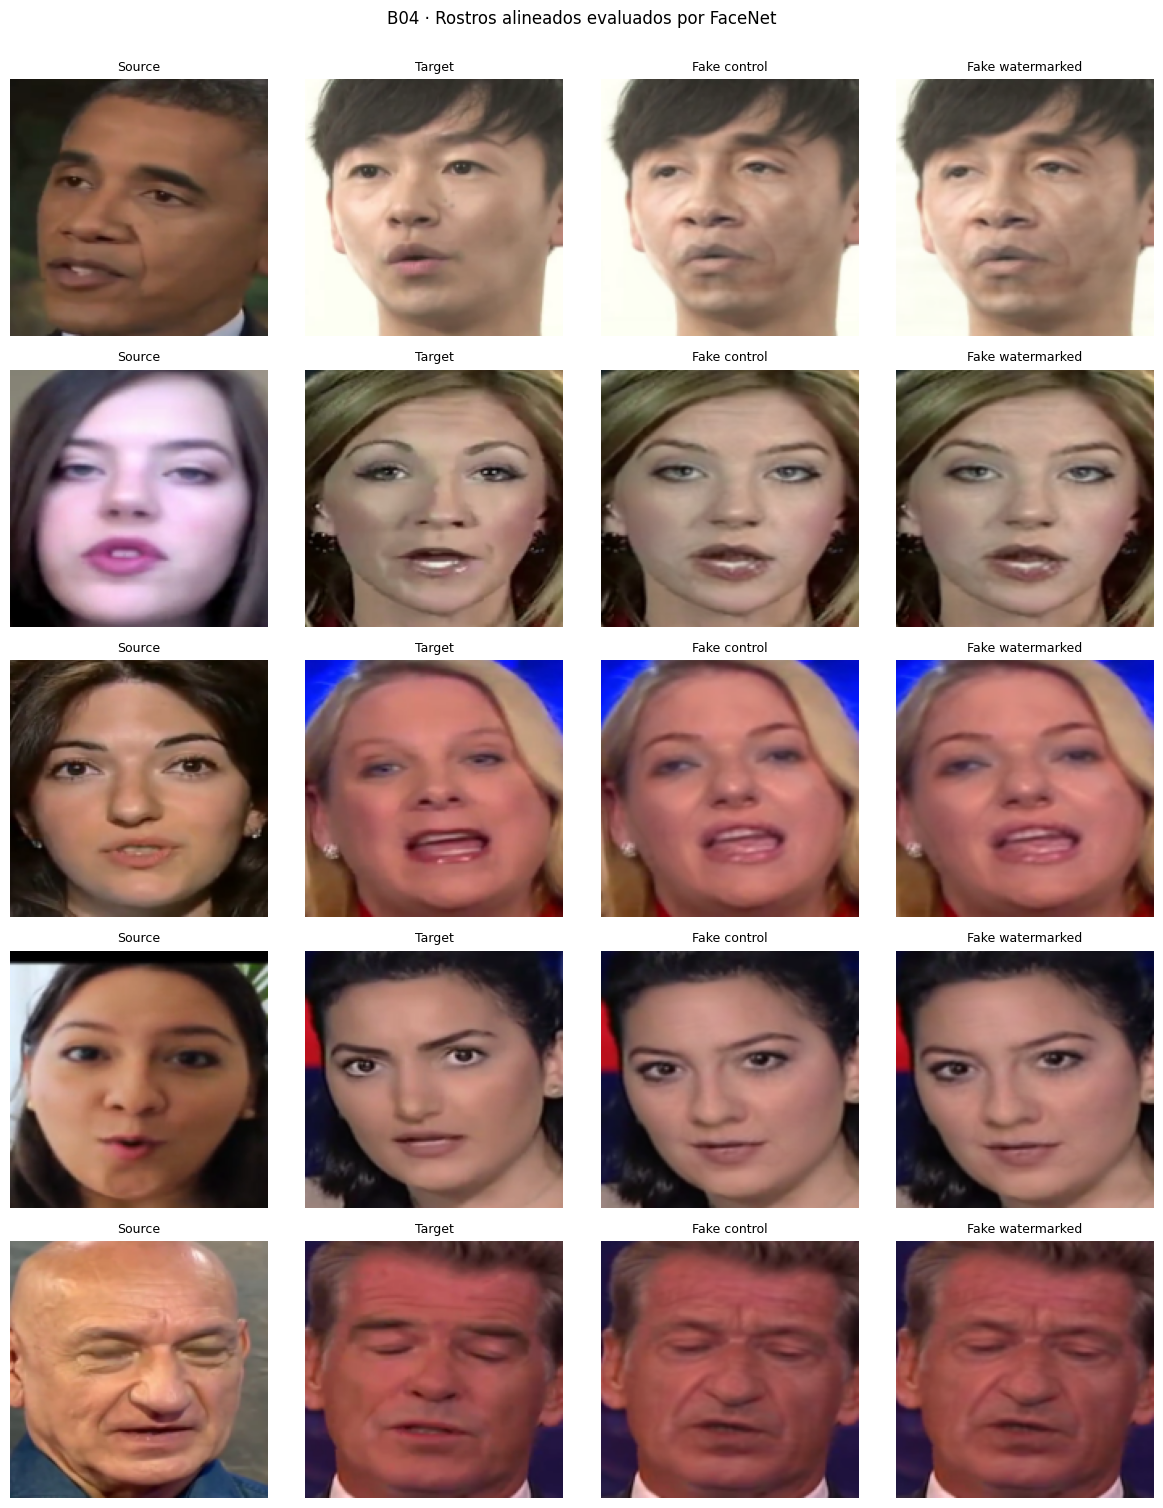

Figura:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/face_swap_validation/aligned_faces_b04.png


In [ ]:
# ============================================================
# CELDA 18 — Inspección de rostros alineados
# Muestra exactamente los crops faciales utilizados por el
# verificador independiente: source, target, fake_control y
# fake_watermarked. Esta figura permite auditar visualmente las
# comparaciones de identidad calculadas por B04.
# ============================================================

n = len(
    manifest_b02
)

fig, axes = plt.subplots(
    n,
    4,
    figsize=(
        12,
        3 * n,
    ),
)

if n == 1:
    axes = np.array(
        [axes]
    )


roles = [
    "source",
    "target",
    "fake_control",
    "fake_watermarked",
]

titles = [
    "Source",
    "Target",
    "Fake control",
    "Fake watermarked",
]


for i, row in enumerate(
    manifest_b02.itertuples(
        index=False
    )
):

    pair_id = str(
        row.pair_id
    )

    for j, (
        role,
        title,
    ) in enumerate(
        zip(
            roles,
            titles,
        )
    ):

        path = Path(
            embedding_records[
                pair_id
            ][
                role
            ][
                "aligned_path"
            ]
        )

        with Image.open(
            path
        ) as img:

            image = (
                img
                .convert("RGB")
                .copy()
            )


        axes[
            i,
            j,
        ].imshow(
            image
        )

        axes[
            i,
            j,
        ].set_title(
            title,
            fontsize=9,
        )

        axes[
            i,
            j,
        ].axis(
            "off"
        )


    axes[
        i,
        0,
    ].set_ylabel(
        pair_id
    )


plt.suptitle(
    "B04 · Rostros alineados evaluados por FaceNet",
    y=1.002,
)

plt.tight_layout()

plt.savefig(
    FIG_ALIGNED,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Figura:")
print(FIG_ALIGNED)


In [ ]:
# ============================================================
# CELDA 19 — Resumen final de B04
# Presenta la evidencia principal necesaria para interpretar B03:
# si el face swap fue exitoso en ambas ramas y si insertar
# TrustMark afectó apreciablemente la transferencia de identidad.
# ============================================================

s = summary.iloc[
    0
]


print(
    "============================================================"
)

print(
    " B04 COMPLETADO"
)

print(
    "============================================================"
)

print()

print(
    f"Pares evaluados:                "
    f"{int(s['n_pairs'])}"
)

print()

print(
    "FACE SWAP CONTROL"
)

print(
    f"Success rate:                   "
    f"{s['control_success_rate']:.3f}"
)

print(
    f"Mean source similarity:         "
    f"{s['mean_control_source_similarity']:.3f}"
)

print(
    f"Mean identity margin:           "
    f"{s['mean_control_identity_margin']:.3f}"
)

print()

print(
    "FACE SWAP DESDE TARGET MARCADO"
)

print(
    f"Success rate:                   "
    f"{s['watermarked_success_rate']:.3f}"
)

print(
    f"Mean source similarity:         "
    f"{s['mean_watermarked_source_similarity']:.3f}"
)

print(
    f"Mean identity margin:           "
    f"{s['mean_watermarked_identity_margin']:.3f}"
)

print()

print(
    "CONTROL vs WATERMARKED"
)

print(
    f"Delta source similarity:        "
    f"{s['mean_delta_source_similarity_wm_minus_control']:.4f}"
)

print(
    f"Identity similarity outputs:    "
    f"{s['mean_fake_identity_similarity_control_vs_watermarked']:.3f}"
)

print(
    f"SSIM outputs:                   "
    f"{s['mean_control_vs_watermarked_ssim']:.4f}"
)

print()

print(
    "Interpretación:"
)

print(
    "Si ambas success rates son altas y las dos ramas "
    "muestran métricas de identidad similares, entonces la "
    "supervivencia observada en B03 ocurrió después de un "
    "face swap que sí produjo el desplazamiento de identidad."
)

print()
print(
    "Nota: con n=5 este resultado sigue siendo un smoke test "
    "descriptivo y no una validación biométrica general."
)


 B04 COMPLETADO

Pares evaluados:                5

FACE SWAP CONTROL
Success rate:                   1.000
Mean source similarity:         0.630
Mean identity margin:           0.311

FACE SWAP DESDE TARGET MARCADO
Success rate:                   1.000
Mean source similarity:         0.628
Mean identity margin:           0.316

CONTROL vs WATERMARKED
Delta source similarity:        -0.0020
Identity similarity outputs:    0.994
SSIM outputs:                   0.9858

Interpretación:
Si ambas success rates son altas y las dos ramas muestran métricas de identidad similares, entonces la supervivencia observada en B03 ocurrió después de un face swap que sí produjo el desplazamiento de identidad.

Nota: con n=5 este resultado sigue siendo un smoke test descriptivo y no una validación biométrica general.
